# Weeks 1-3 Example Notebook

This notebook has examples of use for each of the functions contained within the weeks123_functions.py file. These functions were created as part of an introduction to working with Github and to become familiar with the project areas later in the course. The functions included here are mostly simple and unrelated to the main project. The periodic fitting functions that were created have been adapted for the project and moved to the file tfp.py. See TFP_examples for details.

In [2]:
# Import required for each of the functions in this section
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy.optimize import minimize
from sklearn import cluster
from sklearn.cluster import KMeans

# Importing the relevant section of the package
import ACPP_Bunjy.weeks123_functions as f123

## Week 1 Doubling Function

Most of the work in the first week related to creation and set up of the Github repository. This test function is extremely simple, taking a float or int input and multiplying the value by two. The purpose of this function was to develop a function that could be uploaded to the repo and imported for use into Jupyter hub.

In [3]:
f123.double(21)

42

## Week 2 Functions

### Straight line fitting functions

Functions designed in week 2 are all related to fitting curves to data. The first of these is a simple function of a straight line, of the typical form:

$y = mx+c$

The function takes an array of x values, along with int or float values each for m and c to then return an array of y values.

In [4]:
# Creating a small random dataset for testing
w2ex_x = np.array([1,1.5,3,4.5,5])
m = 2
c = 5

# Inputting example values to the function and printing the determined y-value array
w2ex_y = f123.straight_line(w2ex_x, m, c)
print(w2ex_y)

[ 7.  8. 11. 14. 15.]


From this, the straightline_fitter function was then developed to fit a straight line function to a matched set of x and y data, determining the gradient and y-intercept of the line. It applies Scipy's optimize function to determine the values, associated errors and the $R^2$ of the line fit. Optionally, a plot can also be made of the data and line, and the residual difference between the two for visual checks of the function operating correctly. As standard, the function will return the params, errors and $R^2$ as outputs.

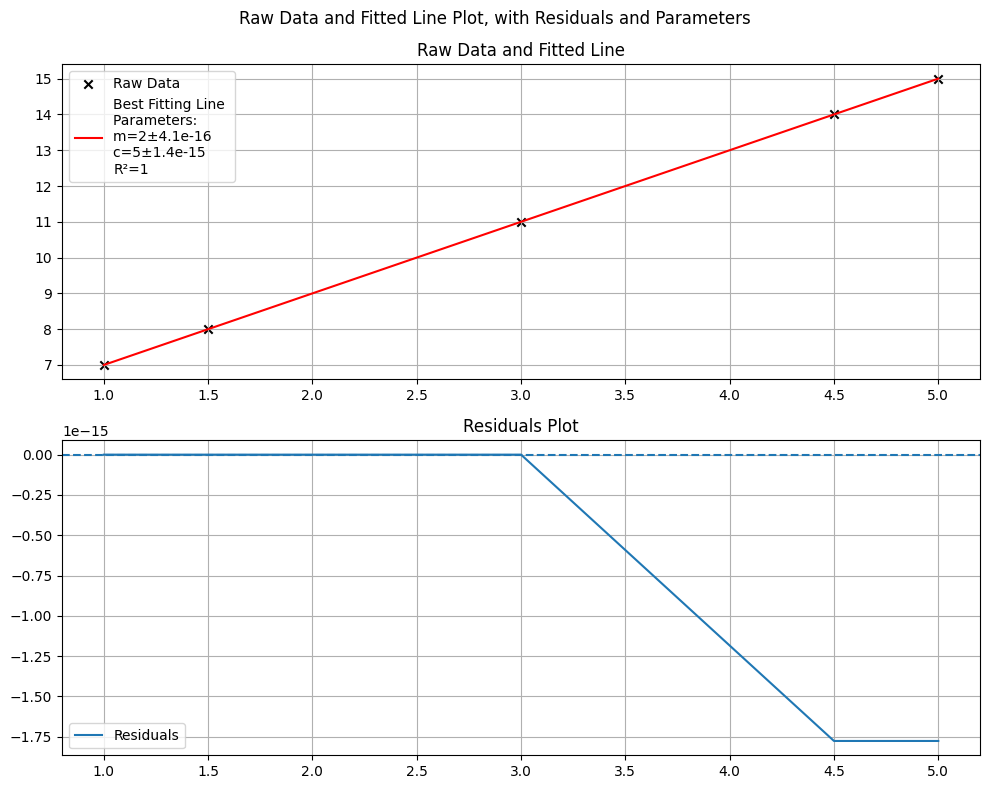

(array([2., 5.]), array([4.10232040e-16, 1.39116453e-15]), 1.0)

In [5]:
f123.straightline_fitter(w2ex_x, w2ex_y, plotting=True)

### Polynomial Fitting Functions

The next function created for this week is a more advanced version of the straight line fitter, able to fit a generic polynomial of order between 1 and 6 to a given dataset, containing x and y data. An additional argument is taken compared to before, being a guess of the fitted parameters from which the function determines the best fitting set. It again applies Scipy's optimize curve fit, and as before will return parameters corresponding to each $x^n$ term, with an associated error and the $R^2$ of the fit. The example shown below uses an example dataset of a magnetic hysteresis curve for demonstration.

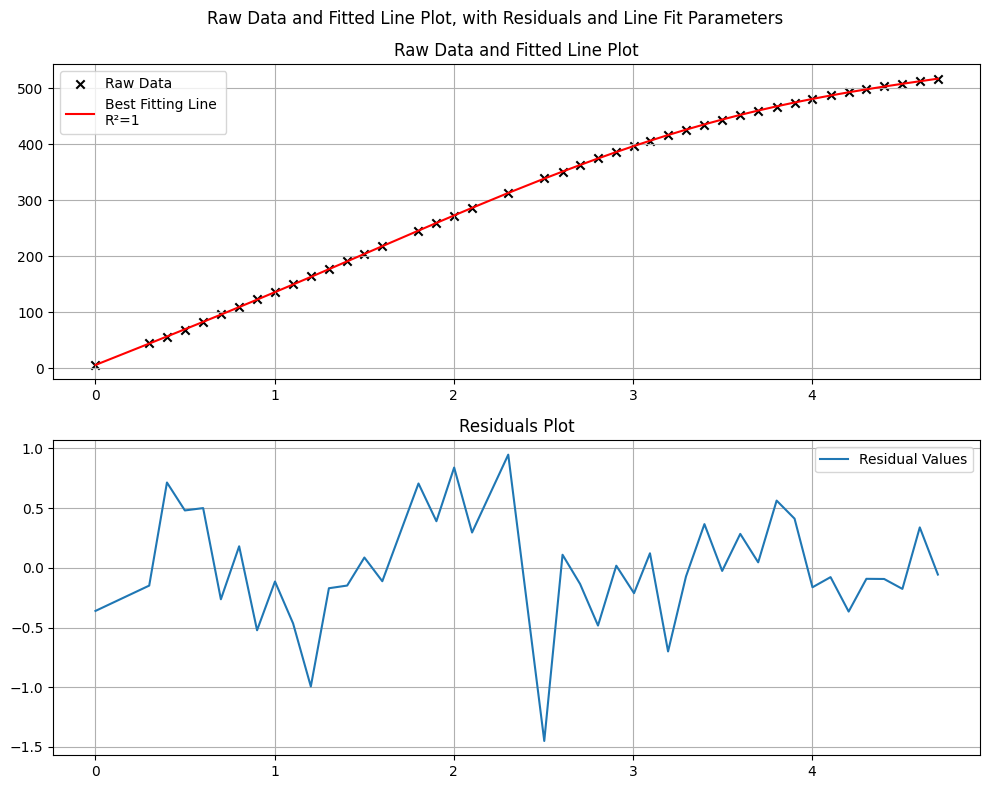

(array([  5.84911196, 127.62932651,  -3.12001765,   8.10982554,
         -3.14535242,   0.2934062 ]),
 array([0.45388775, 1.77328549, 2.31322732, 1.24259846, 0.28988458,
        0.0243892 ]),
 0.9999914830045983)

In [6]:
# Example data for testing, change as necessary
import os
current_directory = os.getcwd()
data_poly = np.load(current_directory+'/I_B_calibration_NMR1.npy')

# Setting the axes of data for fitting
current = data_poly[:,0]
Bfield = data_poly[:,1]

# Fitting a fifth order polynomial
f123.polynomial_fitter(current, Bfield, 5, [1,100,0,0,0,0], plotting=True)

## Week 3 Functions
### Signal Minimising

The first function of the third week takes a known periodic signal and applies a minimisation process to reconstruct the signal's parameters and form. It introduces the concept of minimisation for the project areas but the function has little utility otherwise. The parameters and returns of the function are listed below.

    Parameters
    ----------
    tau_vals : array-like
        Array containing the tau values of each function component.
        
    linear_vals : array-like
        The original weighting values of each tau-function.
        
    t_final : int or float
        End time value of the signal on the x-axis.
        
    x0_vals : array-like
        Initial guesses of the linear_vals array for minimisation.
        
    plot : bool, optional
        Toggle to plot the results of the function.
    
    Returns
    -------
    min_vals : numpy.ndarray
        The minimised weighting values found by the function.
        
    fmin_vals : numpy.ndarray
        The reconstructed signal using min_vals.


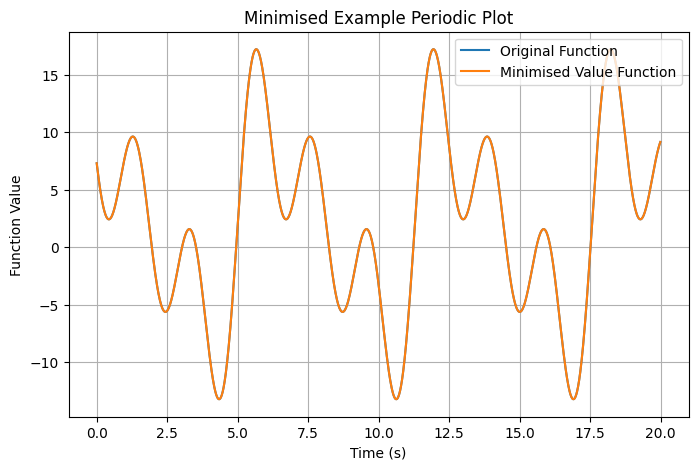

(array([7.99999999, 3.99999999, 6.99999999, 1.99999999]),
 array([7.29546375, 7.09275405, 6.89266981, ..., 9.00195825, 9.074269  ,
        9.14248468]))

In [7]:
# Random Example Values for demonstration
tau_vals = [5,10,15]
linear_vals = [8,4,7,2]
x0_vals = [1,2,3,4]
t_end = 20

# Running the function with plotting enabled to show results.
f123.signal_minimise(tau_vals, linear_vals, t_end, x0_vals, plot=True)

### Numpy SVD Algorithm

This function applies Numpy's singular value decomposition (SVD) algorithm to a 3D dataset. It computes the SVD and returns the matrices U, S, and V, with a set of loading maps derived from the specified number of components. This function was the beginning of working with SVD and decomposition algorithms that would later become the primary focus of my project, all of the following work was done using the Hyperspy framework for SVD, the Numpy example shown and used by this function is mostly for demontration and introduction to the concept. Listed below are the inputs and outputs of the svd_alg function.
    
    Parameters
    ----------
    input_data : numpy.ndarray
        A three-dimensional array containing the input dataset.
    load_val : int
        The desired number of loading maps.

    Returns
    -------
    U : numpy.ndarray
        Left singular vectors of the reshaped data matrix.
    S : numpy.ndarray
        Singular values corresponding to the decomposition.
    V : numpy.ndarray
        Right singular vectors of the reshaped data matrix.
    loadings_set : list
        A list containing the calculated loading maps up to the specified index.

In this instance, the function is applied to a small example dataset of electron scattering from a crystal lattice, taken with an electron microscope.

In [8]:
# Importing Example Data for testing
current_directory = os.getcwd()
data_svd = np.load(current_directory+'/binned_diff_20210421_160712_PT1D.npy')

# Running algorithm and returning found vector arrays
f123.svd_alg(data_svd, 4)

(array([[-2.75740349e-02,  8.82489639e-03, -6.29274377e-03, ...,
         -1.00342452e-02, -4.52999898e-02, -1.61298879e-02],
        [-2.59939090e-02,  2.66261573e-02, -4.56865324e-02, ...,
         -4.63622183e-02,  8.42014888e-03, -6.95674889e-03],
        [-2.83606048e-02,  2.09288359e-02, -3.97242201e-02, ...,
          1.50803751e-02, -5.86111391e-02,  2.09370823e-02],
        ...,
        [-2.64773167e-02,  1.79418663e-02,  2.12776464e-02, ...,
          6.78060637e-01, -3.26455548e-03,  2.22261863e-02],
        [-2.76853821e-02,  1.55232490e-02,  4.25255608e-02, ...,
         -1.44767191e-02,  7.44759504e-01, -6.31699480e-04],
        [-2.70646991e-02,  1.14421595e-02,  4.36732348e-02, ...,
          1.74831028e-02,  1.34400492e-02,  7.24552693e-01]]),
 array([4.54235984e+04, 3.64329140e+03, 1.84168937e+03, 1.55973886e+03,
        1.24931997e+03, 9.89126403e+02, 9.52234144e+02, 9.11375961e+02,
        8.75689253e+02, 8.54444390e+02, 8.46637156e+02, 8.12182131e+02,
        7.976

### Clustering Algorithm

The final function from the individual lab sessions is a function to implement the clustering algorithms from the sklearn package, using either the KMeans or DBSCAN algorithm in the process. This was another introduction to a project area I did not pursue so while the function has utility in clustering, it has little application to the rest of the work I completed. From initial testing here though, it can broadly be seen that DBSCAN has a superior performance of the two algorithms, with superior distinction of patterns in the data and filtering of outliers. The example data used is of a crystal lattice diffraction pattern, and examples are given for both algorithms. Below are the inputs and outputs of the function.

    Parameters
    ----------
    input_data : numpy.ndarray
        A two-dimensional array containing the dataset to be clustered.
    method : str, optional
        The clustering algorithm to use. Must be either "KMeans" or "DBSCAN".
        Default is "KMeans".
    n_clusters : int, optional
        The number of clusters to form (KMeans specific).
    eps : float, optional
        The maximum distance between samples for them to be considered part of
        the same neighbourhood (DBSCAN specific).
    min_samples : int, optional
        The minimum number of samples required to form a cluster (DBSCAN specific).

    Returns
    -------
    centers : numpy.ndarray
        The coordinates of the cluster centres.
    labels : numpy.ndarray
        The cluster label assigned to each input data point.

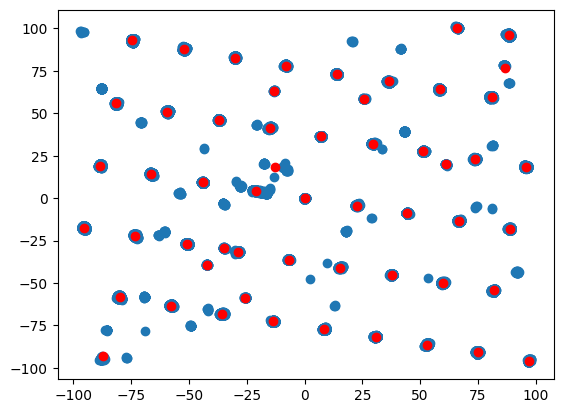

In [9]:
# Importing example clusters dataset
data_clust = np.load('/home/2758304h/examples/p4/PHYS4069P/BFBTgrain_112_pointsarray_bin.npy')
clusters = data_clust[:,:2]

# Running KMeans cluster and plotting
centers, labels = f123.clustering(clusters, method='KMeans', n_clusters=55)

# Plotting results to illustrate KMeans effectiveness
plt.scatter(data_clust[:,0], data_clust[:,1])
plt.scatter(centers[:,0], centers[:,1], color='red')
plt.show()

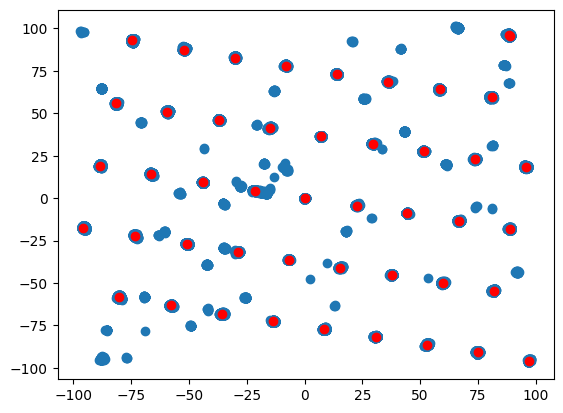

In [10]:
# Running DBSCAN cluster and plotting
centers, labels = f123.clustering(clusters, method='DBSCAN', eps=0.2, min_samples=100)

# PLotting results to show DBSCAN effectiveness
plt.scatter(data_clust[:,0], data_clust[:,1])
plt.scatter(centers[:,0], centers[:,1], color='red')
plt.show()